# APR(에이피알) 미국 선행지표 — Amazon / Keepa 파이프라인 V4

`apr_us_amazon_keepa_v4.ipynb`

---

## 목적

Keepa API로 메디큐브 ASIN들의 **BSR·가격·리뷰 히스토리를 백필**하고,
브랜드 단위 지수로 합성해 APR 분기 미국 매출과의 **시차 상관을 검증**한다.

Keepa의 유일한 독점 영역은 **과거 히스토리**다. 오늘 구축해서 오늘 백테스트가
가능한 유일한 경로이며, 이것이 €49의 실질적인 구매 대상이다.

## 파이프라인

```
ASIN 발굴 (Product Finder)  →  마스터 테이블
        ↓
배치 백필 (토큰 예산 관리)   →  일별 패널 (BSR/가격/리뷰/오퍼)
        ↓
품질 처리 (OOS 마스킹 / 리뷰 리셋 / variation 롤업)
        ↓
브랜드 지수 3종  →  APR 분기 매출과 시차 상관
```

## 지수 설계

BSR은 판매량이 아니라 **순위**다. 판매량은 대략 멱함수 관계를 따른다.

```
sales_proxy_i(t) = BSR_i(t) ** (-ALPHA)          # ALPHA는 자유 파라미터
gmv_proxy_i(t)   = price_i(t) * sales_proxy_i(t)

gmv_index_all(t)   = Σ_i gmv_proxy_i(t)           # 전체 (SKU 확장 포함)
gmv_index_fixed(t) = Σ_i∈B gmv_proxy_i(t)         # 고정 바스켓 (like-for-like)
brand_strength(t)  = Σ_i w_i(t) × (−log BSR_i(t)) # 가중 로그순위
```

`gmv_index_all` 과 `gmv_index_fixed` 의 분리가 핵심이다.
전자는 **SKU 확장을 포함한 총성장**, 후자는 **기존 SKU의 자체 모멘텀**이다.
소매업의 총매출 대 동일점포매출과 같은 구분이며, 둘이 벌어지면
성장이 신제품 출시에 의존하고 있다는 뜻이다.

## 주의

- `ALPHA`는 카테고리·시즌마다 달라지는 **자유 파라미터**다. 단일 값을 믿지 말고
  마지막 장의 민감도 표를 반드시 확인할 것.
- 절대 판매량 추정은 하지 않는다. **상대 변화만** 신뢰 구간 안에 있다.
- 검증 표본은 분기 8~12개. 회귀 불가, 부호 일관성 판단만 유효.

---
## V4 변경사항

| 항목 | 내용 |
|---|---|
| DB 연결 | `config.get_engine(config.get_db_info())` 규약으로 교체. 실패 시 3단계 폴백 + 진단 출력 |
| `sys.path` | `config.py` 가 `from DATA.stock_invest_function import ...` 로 import 하므로 프로젝트 루트도 추가 |
| 경로 탐지 | 5단계 자동탐지 (override / 환경변수 / cwd 상위탐색 / 고정경로 / 홈 얕은탐색) |
| API 키 | 노트북 밖 `keepa_config.json` 에서 로드. 6개 위치 탐색, JSON 오류·예시값 진단 |
| Product Finder | `page` 파라미터 제거 (REQUEST_REJECTED 원인). `perPage` 단일 요청으로 변경 |
| 브랜드 검증 | 백필 전 `history=False` 메타 조회로 타 브랜드·리셀러 ASIN 사전 제거 |
| 가격 정규화 | 센트/달러 판별을 정수 여부 + 임계값 조합으로 강화 |
| **`FFILL_LIMIT_D` 7 → 21** | 7일은 Keepa 갱신 주기보다 짧아 커버리지 톱니(활성 ASIN 40↔5 진동)를 유발했다 |
| 보간 비율 경고 | `is_ffilled` 비율이 60%를 넘으면 경고. 그 지수는 관측이 아니라 추정에 가깝다 |

---
**V4** | 2026-08

## 1. 사용자 입력 변수

> 이 노트북에서 사용자가 조정하는 변수는 **이 셀에만** 존재한다.
> API 키는 여기에 넣지 않는다 (2장에서 외부 파일로 로드).

In [1]:
# ============================================================================
# USER INPUT — 이 셀만 수정하면 된다
# ============================================================================

# ---------- 대상 브랜드 / 종목 ----------
TICKER          = "A278470"      # APR 종목코드 (다종목 확장 대비 마스터 키)
COMPANY         = "APR"         # 회사명
BRAND_NAMES     = ["medicube", "Medicube", "MEDICUBE"]  # Product Finder 브랜드 필터 후보
DOMAIN          = "US"          # Keepa 마켓플레이스 (US / JP / DE ...)

# ---------- ASIN 발굴 ----------
ASIN_SOURCE     = "both"        # 'finder' / 'manual' / 'both'
FINDER_MAX      = 50            # Product Finder 최대 수집 ASIN 수 (perPage, 최대 50 권장)

# Finder 결과에 리셀러의 타 브랜드 상품이 섞이므로 백필 전에 거른다.
VERIFY_BRAND    = True          # 브랜드 검증 단계 실행 여부
BRAND_MATCH_KEYS = ["medicube", "메디큐브", "age-r", "ager"]  # 이 중 하나라도 걸리면 유지

# 수동 시드 ASIN — Product Finder 실패 시 백업. Amazon US 상품 URL에서 확인 가능.
# 예: amazon.com/dp/B0XXXXXXXX → 'B0XXXXXXXX'
MANUAL_ASINS = [
    # "B0XXXXXXXX",   # Zero Pore Pad 2.0
    # "B0XXXXXXXX",   # Collagen Night Wrapping Mask
    # "B0XXXXXXXX",   # PDRN Pink Collagen
    # "B0XXXXXXXX",   # AGE-R Booster Pro (device)
]

# 디바이스로 분류할 키워드 (마진 구조가 달라 별도 집계)
DEVICE_KEYWORDS = ["age-r", "ager", "booster", "device", "shower", "ultra tune", "derma"]

# ---------- 수집 옵션 ----------
FETCH_RATING    = True          # 리뷰수·평점 히스토리 포함 (ASIN당 토큰 +1)
FETCH_OFFERS    = False         # 오퍼 히스토리 — 토큰 급증. 권장: False
BATCH_SIZE      = 20            # 1회 query 당 ASIN 수
TOKENS_PER_ASIN = 2             # 예산 추정용 (base 1 + rating 1)
TOKEN_SAFETY    = 50            # 이만큼 토큰이 남도록 보수적으로 중단
WAIT_FOR_TOKENS = True          # 토큰 소진 시 대기 (False면 즉시 실패)

# ---------- 패널 구성 ----------
FFILL_LIMIT_D   = 21            # 결측 forward-fill 최대 일수
                                # (V2의 7일은 너무 짧아 커버리지 톱니를 유발했다.
                                #  Keepa는 저순위 상품을 드물게 갱신한다.
                                #  단 is_ffilled=0 이 실관측을 표시하므로,
                                #  조회 노트북 V4에서 재보간이 가능하다 = 재수집 불필요)
MIN_HISTORY_D   = 90            # 이 일수 미만 이력의 ASIN은 지수에서 제외
FIXED_BASKET_DATE = None        # 고정 바스켓 기준일 (None이면 자동: 최근 24개월 전)

# ---------- 지수 파라미터 ----------
ALPHA           = 0.70          # BSR → 판매량 멱지수. 민감도 반드시 확인
ALPHA_GRID      = [0.5, 0.6, 0.7, 0.8, 0.9]   # 민감도 분석 그리드
USE_SUBCAT_BSR  = False         # True=서브카테고리 BSR, False=루트 BSR

# ---------- DB ----------
SAVE_TO_DB      = True
CREATE_TABLES   = True
COLLECTED_AT    = None          # vintage. None이면 오늘
TBL_ASIN_MASTER = "amazon_asin_master"
TBL_BSR_DAILY   = "amazon_bsr_daily"
TBL_BRAND_INDEX = "amazon_brand_index"
TBL_COLLECT_LOG = "amazon_collect_log"
TBL_APR_ACTUAL  = "apr_us_quarterly_actual"   # Trends 노트북과 공유

# ---------- 검증 ----------
LAG_RANGE       = [0, 1, 2, 3]
MIN_OBS_FOR_CORR = 5
RESAMPLE_RULE   = "QE"

# ---------- 시각화 ----------
SHOW_PLOTS      = True
FIG_SIZE        = (14, 4)


## 2. 환경 설정 · API 키 로드

**API 키는 노트북에 하드코딩하지 않는다.** 다음 순서로 탐색한다.

1. 환경변수 `KEEPA_API_KEY`
2. `DATA/keepa_config.json` 의 `{"api_key": "..."}`

노트북을 공유하거나 git에 올려도 키가 새지 않는다.
`keepa_config.json` 은 반드시 `.gitignore` 에 추가할 것.

In [2]:
import os
import sys
import json
import time
import math
import warnings
from datetime import date, datetime, timedelta
from typing import Optional, Union, List, Dict, Any, Tuple

import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 220)

# ============================================================================
# 경로 자동탐지 — 데스크톱 / 노트북 어디서 실행해도 DATA/ 를 찾아낸다
# ============================================================================
# 탐색 순서:
#   1) BASE_PATH_OVERRIDE (수동 지정)
#   2) 환경변수 STOCK_BASE_PATH
#   3) 현재 작업 디렉토리에서 상위로 6단계
#   4) 알려진 고정 경로
#   5) 홈 디렉토리 기반 얕은 탐색 (OneDrive / 바탕 화면 / Desktop 등)
# ----------------------------------------------------------------------------

BASE_PATH_OVERRIDE = None   # 전부 실패하면 여기에 경로를 직접 문자열로 넣으십시오

KNOWN_PATHS = [
    r"C:\Users\Hoyoung_Park\PyCharmMiscProject\stock_forecast",
    r"C:\Users\82108\OneDrive\바탕 화면\investment\investment_strategy",
]

PROJECT_DIR_NAMES = ["stock_forecast", "investment_strategy", "investment"]


def _has_data(p: Optional[str]) -> bool:
    if not p:
        return False
    try:
        return os.path.isdir(os.path.join(p, "DATA"))
    except Exception:
        return False


def resolve_base_path() -> Tuple[Optional[str], List[Tuple[str, str]]]:
    """DATA/ 를 포함한 프로젝트 루트를 탐색. (경로, 시도이력) 반환."""
    tried: List[Tuple[str, str]] = []

    # (1) 수동 지정
    if BASE_PATH_OVERRIDE:
        tried.append(("override", BASE_PATH_OVERRIDE))
        if _has_data(BASE_PATH_OVERRIDE):
            return BASE_PATH_OVERRIDE, tried

    # (2) 환경변수
    envp = os.environ.get("STOCK_BASE_PATH")
    if envp:
        tried.append(("env", envp))
        if _has_data(envp):
            return envp, tried

    # (3) cwd에서 상위로 — 노트북이 프로젝트 하위 어디에 있어도 잡힌다
    cur = os.path.abspath(os.getcwd())
    for _ in range(6):
        tried.append(("cwd-up", cur))
        if _has_data(cur):
            return cur, tried
        parent = os.path.dirname(cur)
        if parent == cur:
            break
        cur = parent

    # (4) 알려진 고정 경로
    for p in KNOWN_PATHS:
        tried.append(("known", p))
        if _has_data(p):
            return p, tried

    # (5) 홈 기반 얕은 탐색 — OneDrive / 한글·영문 바탕화면 변형 모두 대응
    home = os.path.expanduser("~")
    roots = [
        home,
        os.path.join(home, "OneDrive"),
        os.path.join(home, "Desktop"),
        os.path.join(home, "바탕 화면"),
        os.path.join(home, "OneDrive", "Desktop"),
        os.path.join(home, "OneDrive", "바탕 화면"),
        os.path.join(home, "Documents"),
        os.path.join(home, "PyCharmMiscProject"),
    ]
    for root in roots:
        if not os.path.isdir(root):
            continue
        tried.append(("home", root))
        if _has_data(root):
            return root, tried
        for nm in PROJECT_DIR_NAMES:
            cand = os.path.join(root, nm)
            if _has_data(cand):
                return cand, tried
        # 한 단계 더 들어가서 확인
        try:
            for sub in sorted(os.listdir(root)):
                subp = os.path.join(root, sub)
                if not os.path.isdir(subp):
                    continue
                if _has_data(subp):
                    return subp, tried
                for nm in PROJECT_DIR_NAMES:
                    cand = os.path.join(subp, nm)
                    if _has_data(cand):
                        return cand, tried
        except (PermissionError, OSError):
            continue

    return None, tried


BASE_PATH, _tried = resolve_base_path()

if BASE_PATH is None:
    print("=" * 78)
    print("[ERROR] DATA/ 폴더를 포함한 프로젝트 루트를 찾지 못했습니다.")
    print("=" * 78)
    print("\n시도한 경로 (%d개):" % len(_tried))
    for how, p in _tried[:20]:
        print("  [%-8s] %s" % (how, p))
    print("\n해결 방법 — 아래 중 하나:")
    print("  (A) 이 셀 상단의 BASE_PATH_OVERRIDE 에 경로를 직접 입력")
    print(r"      예: BASE_PATH_OVERRIDE = r'D:\work\investment_strategy'")
    print("  (B) 환경변수 STOCK_BASE_PATH 설정 후 Jupyter 재시작")
    print('      PowerShell:  setx STOCK_BASE_PATH "D:\\work\\investment_strategy"')
    print("  (C) KNOWN_PATHS 리스트에 이 PC의 경로를 추가")
    print("\n현재 작업 디렉토리:", os.getcwd())
    BASE_PATH = os.getcwd()
    DATA_PATH = os.path.join(BASE_PATH, "DATA")
else:
    DATA_PATH = os.path.join(BASE_PATH, "DATA")
    print("BASE_PATH :", BASE_PATH)
    print("DATA_PATH :", DATA_PATH)

if DATA_PATH not in sys.path:
    sys.path.append(DATA_PATH)
# config.py 가 `from DATA.stock_invest_function import ...` 형태로 import 하므로
# DATA/ 뿐 아니라 그 부모(프로젝트 루트)도 sys.path 에 있어야 한다.
if BASE_PATH not in sys.path:
    sys.path.insert(0, BASE_PATH)

print("python    :", sys.version.split()[0])
print("pandas    :", pd.__version__)


# ---------------------------------------------------------------- resample 호환
def _resample_rule() -> str:
    try:
        _mj, _mn = int(pd.__version__.split(".")[0]), int(pd.__version__.split(".")[1])
    except Exception:
        return "Q"
    return "QE" if (_mj, _mn) >= (2, 2) else "Q"

RESAMPLE_RULE_EFF = _resample_rule()
COLLECTED_AT_EFF = pd.to_datetime(COLLECTED_AT).date() if COLLECTED_AT else date.today()
print("resample  :", RESAMPLE_RULE_EFF)
print("vintage   :", COLLECTED_AT_EFF)


BASE_PATH : C:\Users\82108\OneDrive\바탕 화면\investment\investment_strategy
DATA_PATH : C:\Users\82108\OneDrive\바탕 화면\investment\investment_strategy\DATA
python    : 3.9.10
pandas    : 2.2.2
resample  : QE
vintage   : 2026-08-03


In [3]:
# ---------------------------------------------------------------- API 키 로드
KEEPA_CONFIG_PATH = os.path.join(DATA_PATH, "keepa_config.json")

# 설정 파일 탐색 후보 — DATA/ 를 못 찾은 경우에도 살아남도록 여러 곳을 본다
KEY_SEARCH_PATHS = [
    KEEPA_CONFIG_PATH,
    os.path.join(BASE_PATH, "keepa_config.json"),
    os.path.join(os.getcwd(), "keepa_config.json"),
    os.path.join(os.getcwd(), "DATA", "keepa_config.json"),
    os.path.join(os.path.expanduser("~"), "keepa_config.json"),
    os.path.join(os.path.expanduser("~"), ".keepa", "config.json"),
]


def load_keepa_key() -> Optional[str]:
    """환경변수 → 설정파일(여러 위치) 순으로 탐색."""
    k = os.environ.get("KEEPA_API_KEY")
    if k and k.strip():
        print("[KEY] 환경변수 KEEPA_API_KEY 사용")
        return k.strip()

    seen = set()
    for path in KEY_SEARCH_PATHS:
        if path in seen or not os.path.exists(path):
            continue
        seen.add(path)
        try:
            with open(path, "r", encoding="utf-8") as f:
                cfg = json.load(f)
            k = cfg.get("api_key")
            if k and k.strip() and not k.strip().startswith("여기에"):
                print("[KEY] %s 사용" % path)
                return k.strip()
            print("[KEY] %s — api_key 값이 비었거나 예시 그대로입니다" % path)
        except json.JSONDecodeError as e:
            print("[KEY] %s — JSON 형식 오류: %s" % (path, str(e)[:100]))
            print("      따옴표는 반드시 큰따옴표(\") 여야 하고, 마지막 항목 뒤에 쉼표가 없어야 합니다.")
        except Exception as e:
            print("[KEY] %s — 읽기 실패: %s" % (path, repr(e)[:100]))

    return None


KEEPA_KEY = load_keepa_key()

if not KEEPA_KEY:
    print("=" * 78)
    print("API 키를 찾지 못했습니다. 아래 중 하나를 수행하십시오.")
    print("=" * 78)
    print()
    print("  [방법 1] 설정 파일 생성 (권장)")
    print("      아래 경로 중 아무 곳에나 keepa_config.json 을 두면 됩니다:")
    for _p in KEY_SEARCH_PATHS:
        print("        %s" % _p)
    print()
    print("      파일 내용:")
    print('        {"api_key": "여기에_키_붙여넣기"}')
    print()
    print("  [방법 2] 환경변수")
    print("      Windows PowerShell:")
    print('          setx KEEPA_API_KEY "여기에_키"')
    print("      설정 후 Jupyter 재시작 필요")
    print()
    print("  * 키를 노트북 셀에 직접 적지 마십시오. 공유·커밋 시 그대로 노출됩니다.")
    print("  * keepa_config.json 은 .gitignore 에 추가하십시오.")
    print("=" * 78)
else:
    print("[KEY] 로드 완료 (앞 4자리: %s..., 길이 %d)" % (KEEPA_KEY[:4], len(KEEPA_KEY)))


[KEY] C:\Users\82108\OneDrive\바탕 화면\investment\investment_strategy\DATA\keepa_config.json 사용
[KEY] 로드 완료 (앞 4자리: 5f6l..., 길이 64)


## 3. DB 연결 · 스키마

**처음부터 다종목 대응 스키마**로 만든다. `ticker` 컬럼을 넣어두면
나중에 K뷰티·K푸드 종목을 추가할 때 마이그레이션이 필요 없다.

`amazon_collect_log` 를 두는 이유는 토큰이 1시간 만에 소멸하는 구조라,
어느 배치에서 무엇을 받았고 몇 토큰을 썼는지 남기지 않으면
중단 후 재개 계획을 세울 수 없기 때문이다.

In [4]:
from sqlalchemy import text

ENGINE = None
DB_AVAILABLE = False
DB_INFO = {}


def make_engine():
    """프로젝트의 DB 접속 규약에 맞춰 엔진을 만든다.

    이 프로젝트는 config.py 가 get_db_info() / get_engine(db_info) 를 제공한다.
    (get_engine 은 stock_invest_function 이 아니라 config 에 있고 인자를 받는다)
    다른 환경에서도 죽지 않도록 여러 경로를 순차 시도한다.
    """
    errs = []

    # (1) config.get_engine(config.get_db_info())  ← 이 프로젝트의 표준
    try:
        import config
        info = config.get_db_info()
        return config.get_engine(info), "config.get_engine(db_info)", info
    except Exception as e:
        errs.append("config(db_info): %s" % repr(e)[:110])

    # (2) config.get_engine() 무인자 변형
    try:
        import config
        return config.get_engine(), "config.get_engine()", {}
    except Exception as e:
        errs.append("config(): %s" % repr(e)[:110])

    # (3) stock_invest_function 에 get_engine 이 있는 경우
    try:
        from stock_invest_function import get_engine as _ge
        try:
            return _ge(), "stock_invest_function.get_engine()", {}
        except TypeError:
            import config
            info = config.get_db_info()
            return _ge(info), "stock_invest_function.get_engine(db_info)", info
    except Exception as e:
        errs.append("sif: %s" % repr(e)[:110])

    raise RuntimeError("모든 DB 연결 경로 실패 -> " + " | ".join(errs))


try:
    ENGINE, _how, DB_INFO = make_engine()
    with ENGINE.connect() as _c:
        _dbname = _c.execute(text("SELECT DATABASE()")).scalar()
    DB_AVAILABLE = True
    print("[DB] 연결 성공 - %s / database=%s" % (_how, _dbname))
except Exception as e:
    print("[DB] 연결 실패:", repr(e)[:280])
    print()
    print("  확인 사항:")
    print("   1) config.py 가 프로젝트 루트(DATA/ 의 부모)에 있는지")
    print("      현재 BASE_PATH: %s" % BASE_PATH)
    print("      config.py 존재: %s" % os.path.exists(os.path.join(BASE_PATH, "config.py")))
    if DB_INFO:
        print("   2) MySQL 서버 기동 여부 - %s:%s / db=%s"
              % (DB_INFO.get("host"), DB_INFO.get("port"), DB_INFO.get("database")))
    else:
        print("   2) MySQL 서버가 기동 중인지, 포트가 열려 있는지")
    print("   3) 수동 테스트:")
    print("      import config; e = config.get_engine(config.get_db_info())")
    print("      from sqlalchemy import text")
    print("      print(e.connect().execute(text('SELECT 1')).scalar())")
    SAVE_TO_DB = False


[DB] 연결 성공 - config.get_engine(db_info) / database=investar


In [5]:
DDL = {}

DDL[TBL_ASIN_MASTER] = """
CREATE TABLE IF NOT EXISTS {t} (
    asin            VARCHAR(16)  NOT NULL,
    domain          VARCHAR(6)   NOT NULL,
    ticker          VARCHAR(20)      NULL,
    company         VARCHAR(60)      NULL,
    brand           VARCHAR(80)      NULL,
    title           VARCHAR(400)     NULL,
    parent_asin     VARCHAR(16)      NULL,
    root_cat_id     BIGINT           NULL,
    root_cat_name   VARCHAR(120)     NULL,
    is_device       TINYINT      NOT NULL DEFAULT 0,
    first_available DATE             NULL,
    first_seen      DATE             NULL,
    last_seen       DATE             NULL,
    is_active       TINYINT      NOT NULL DEFAULT 1,
    updated_at      DATETIME     NOT NULL DEFAULT CURRENT_TIMESTAMP
                                 ON UPDATE CURRENT_TIMESTAMP,
    PRIMARY KEY (asin, domain),
    KEY idx_ticker (ticker),
    KEY idx_parent (parent_asin)
) ENGINE=InnoDB DEFAULT CHARSET=utf8mb4
""".format(t=TBL_ASIN_MASTER)

DDL[TBL_BSR_DAILY] = """
CREATE TABLE IF NOT EXISTS {t} (
    asin            VARCHAR(16)  NOT NULL,
    domain          VARCHAR(6)   NOT NULL,
    date            DATE         NOT NULL,
    bsr_root        INT              NULL,
    bsr_sub         INT              NULL,
    price_new       DECIMAL(10,2)    NULL,
    price_amazon    DECIMAL(10,2)    NULL,
    price_buybox    DECIMAL(10,2)    NULL,
    count_new       INT              NULL,
    review_count    INT              NULL,
    rating          DECIMAL(3,2)     NULL,
    is_oos          TINYINT      NOT NULL DEFAULT 0,
    is_ffilled      TINYINT      NOT NULL DEFAULT 0,
    review_reset    TINYINT      NOT NULL DEFAULT 0,
    created_at      DATETIME     NOT NULL DEFAULT CURRENT_TIMESTAMP,
    PRIMARY KEY (asin, domain, date),
    KEY idx_date (date)
) ENGINE=InnoDB DEFAULT CHARSET=utf8mb4
""".format(t=TBL_BSR_DAILY)

DDL[TBL_BRAND_INDEX] = """
CREATE TABLE IF NOT EXISTS {t} (
    ticker          VARCHAR(20)  NOT NULL,
    domain          VARCHAR(6)   NOT NULL,
    date            DATE         NOT NULL,
    collected_at    DATE         NOT NULL,
    alpha           DECIMAL(4,2) NOT NULL,
    gmv_index_all   DECIMAL(18,6)    NULL,
    gmv_index_fixed DECIMAL(18,6)    NULL,
    gmv_index_dev   DECIMAL(18,6)    NULL,
    brand_strength  DECIMAL(18,6)    NULL,
    n_active_asin   INT              NULL,
    review_velocity DECIMAL(14,4)    NULL,
    created_at      DATETIME     NOT NULL DEFAULT CURRENT_TIMESTAMP,
    PRIMARY KEY (ticker, domain, date, collected_at, alpha)
) ENGINE=InnoDB DEFAULT CHARSET=utf8mb4
""".format(t=TBL_BRAND_INDEX)

DDL[TBL_COLLECT_LOG] = """
CREATE TABLE IF NOT EXISTS {t} (
    id              BIGINT       NOT NULL AUTO_INCREMENT,
    run_ts          DATETIME     NOT NULL,
    ticker          VARCHAR(20)      NULL,
    domain          VARCHAR(6)       NULL,
    batch_no        INT              NULL,
    n_asin_req      INT              NULL,
    n_asin_ok       INT              NULL,
    tokens_before   INT              NULL,
    tokens_after    INT              NULL,
    tokens_used     INT              NULL,
    status          VARCHAR(20)      NULL,
    message         VARCHAR(400)     NULL,
    PRIMARY KEY (id),
    KEY idx_run (run_ts)
) ENGINE=InnoDB DEFAULT CHARSET=utf8mb4
""".format(t=TBL_COLLECT_LOG)

DDL[TBL_APR_ACTUAL] = """
CREATE TABLE IF NOT EXISTS {t} (
    yyyyq           CHAR(6)      NOT NULL,
    region          VARCHAR(30)  NOT NULL,
    channel         VARCHAR(30)  NOT NULL,
    revenue_krw     BIGINT           NULL,
    yoy             DECIMAL(10,4)    NULL,
    source          VARCHAR(120)     NULL,
    note            VARCHAR(255)     NULL,
    created_at      DATETIME     NOT NULL DEFAULT CURRENT_TIMESTAMP,
    PRIMARY KEY (yyyyq, region, channel)
) ENGINE=InnoDB DEFAULT CHARSET=utf8mb4
""".format(t=TBL_APR_ACTUAL)


if DB_AVAILABLE and CREATE_TABLES:
    with ENGINE.begin() as conn:
        for _name, _ddl in DDL.items():
            conn.execute(text(_ddl))
            print("[DDL] %-24s ready" % _name)
else:
    print("[DDL] skip")


[DDL] amazon_asin_master       ready
[DDL] amazon_bsr_daily         ready
[DDL] amazon_brand_index       ready
[DDL] amazon_collect_log       ready
[DDL] apr_us_quarterly_actual  ready


## 4. Keepa 클라이언트 초기화 · 토큰 현황

토큰은 **생성 후 1시간 만에 소멸**한다. 쌓아두고 한 번에 쓰는 구조가 아니라
흐르는 물을 받아 쓰는 구조에 가깝다. 배치 설계가 여기에 좌우된다.

In [6]:
KEEPA_AVAILABLE = False
api = None

if KEEPA_KEY:
    try:
        import keepa
        api = keepa.Keepa(KEEPA_KEY)
        KEEPA_AVAILABLE = True
        print("[Keepa] 클라이언트 초기화 완료 (keepa %s)" % getattr(keepa, "__version__", "?"))
    except ImportError:
        print("[Keepa] 패키지 미설치 → `pip install keepa`")
    except Exception as e:
        print("[Keepa] 초기화 실패:", repr(e)[:250])
        print("        키가 유효한지, API 플랜이 활성 상태인지 확인하십시오.")
else:
    print("[Keepa] API 키 없음 → 수집 단계 건너뜀")


def token_status() -> Dict[str, Any]:
    """토큰 잔량 조회. 실패 시 빈 dict."""
    if not KEEPA_AVAILABLE:
        return {}
    out = {}
    try:
        out["tokens_left"] = int(api.tokens_left)
    except Exception:
        pass
    try:
        out["refill_in_sec"] = float(getattr(api, "time_to_refill", np.nan))
    except Exception:
        pass
    try:
        st = getattr(api, "status", None)
        if isinstance(st, dict):
            out["refill_rate"] = st.get("refillRate")
            out["tokens_consumed"] = st.get("tokensConsumed")
    except Exception:
        pass
    return out


ts = token_status()
if ts:
    print("[토큰] 잔량 %s / 분당 생성 %s" % (ts.get("tokens_left"), ts.get("refill_rate")))
    if ts.get("refill_in_sec"):
        print("       다음 리필까지 %.0f초" % ts["refill_in_sec"])


[Keepa] 클라이언트 초기화 완료 (keepa 1.3.15)
[토큰] 잔량 0 / 분당 생성 None


## 5. ASIN 발굴

Product Finder는 ASIN 목록만 반환한다. 실제 데이터는 `query`로 별도 요청해야 한다.
브랜드 필터가 마켓플레이스마다 표기 차이로 실패할 수 있어,
여러 후보를 순차 시도하고 실패 시 수동 시드로 폴백한다.

In [7]:
def discover_asins_finder(brands: List[str],
                          domain: str,
                          max_n: int) -> List[str]:
    """Product Finder로 브랜드 ASIN 수집.

    주의: `page` 파라미터를 넣으면 백엔드가 REQUEST_REJECTED를 반환한다.
          `perPage` 하나로 단일 요청을 보내는 것이 안전한 형태다.
          `productType`은 리스트가 아니라 정수여야 한다 (여기서는 쓰지 않음).
    """
    if not KEEPA_AVAILABLE:
        return []

    found = []
    for brand in brands:
        # 1순위: brand 필터 + 판매순위 정렬
        param_sets = [
            {"brand": [brand], "sort": [["current_SALES", "asc"]], "perPage": max_n},
            {"brand": [brand], "perPage": max_n},
            {"title": brand, "perPage": max_n},
        ]
        for prm in param_sets:
            try:
                res = api.product_finder(prm, domain=domain)
            except Exception as e:
                print("  [finder] %s 실패: %s" % (list(prm.keys()), repr(e)[:100]))
                continue
            if res:
                found.extend(list(res))
                print("  [finder] brand='%s' %s → %d개"
                      % (brand, list(prm.keys()), len(res)))
                break
        if found:
            break  # 첫 성공 표기에서 중단

    uniq = sorted(set([a for a in found if isinstance(a, str) and len(a) == 10]))
    return uniq[:max_n]


asins_finder = []
if ASIN_SOURCE in ("finder", "both") and KEEPA_AVAILABLE:
    print("[발굴] Product Finder 실행")
    asins_finder = discover_asins_finder(BRAND_NAMES, DOMAIN, FINDER_MAX)
    print("[발굴] Finder 결과: %d개" % len(asins_finder))

asins_manual = [a.strip().upper() for a in MANUAL_ASINS if a and a.strip()]

if ASIN_SOURCE == "finder":
    ASINS_RAW = asins_finder
elif ASIN_SOURCE == "manual":
    ASINS_RAW = asins_manual
else:
    ASINS_RAW = sorted(set(asins_finder) | set(asins_manual))

print("\n[발굴] 후보 ASIN: %d개" % len(ASINS_RAW))
if len(ASINS_RAW) == 0:
    print("""
  ASIN이 하나도 없습니다.
  1) MANUAL_ASINS 에 직접 입력하십시오.
     amazon.com 에서 medicube 검색 → 상품 URL의 /dp/XXXXXXXXXX 부분
  2) 10~30개면 지수 구성에 충분합니다.
""")
else:
    print(ASINS_RAW[:20], "..." if len(ASINS_RAW) > 20 else "")


[발굴] Product Finder 실행
  [finder] brand='medicube' ['brand', 'sort', 'perPage'] → 50개
[발굴] Finder 결과: 50개

[발굴] 후보 ASIN: 50개
['B073ZBXSJD', 'B09C19CGPF', 'B09C1B7BH5', 'B09V7Z4TJG', 'B0BPLYHDPG', 'B0BPXT3GBN', 'B0BRMYHMS5', 'B0CM2PPNMW', 'B0CV7RX6ML', 'B0CW1KV8B6', 'B0D137TMRB', 'B0D16L5F2M', 'B0D2Z3GGCY', 'B0DBF65JYY', 'B0DCJ7952P', 'B0DFG4MRC9', 'B0DGPSZVW3', 'B0DGTMR754', 'B0DPJRS9DS', 'B0DQCJ9T9N'] ...


In [8]:
# ---------------------------------------------------------------- 브랜드 검증
# Product Finder 결과에는 리셀러가 올린 타 브랜드 상품이 섞일 수 있다.
# history=False 로 조회하면 토큰 소모가 적으므로, 백필 전에 한 번 거른다.

ASINS = ASINS_RAW
screen_df = pd.DataFrame()

if VERIFY_BRAND and KEEPA_AVAILABLE and len(ASINS_RAW):
    print("[검증] 브랜드 확인용 메타 조회 (history=False)")
    try:
        meta_only = api.query(ASINS_RAW, domain=DOMAIN, history=False, wait=True)
    except Exception as e:
        print("  실패:", repr(e)[:200])
        meta_only = []

    rows = []
    for p in meta_only:
        title = (p.get("title") or "")
        brand = (p.get("brand") or "")
        tl, bl = title.lower(), brand.lower()
        hit = any(k.lower() in bl or k.lower() in tl for k in BRAND_MATCH_KEYS)
        rows.append({
            "asin": p.get("asin"),
            "brand": brand[:20],
            "title": title[:65],
            "is_device": int(any(k in tl for k in DEVICE_KEYWORDS)),
            "keep": int(hit),
        })

    screen_df = pd.DataFrame(rows)
    if len(screen_df):
        keep_n = int(screen_df["keep"].sum())
        print("  조회 %d개 → 브랜드 일치 %d개 / 제외 %d개"
              % (len(screen_df), keep_n, len(screen_df) - keep_n))
        print()
        print(screen_df.sort_values(["keep", "asin"], ascending=[False, True])
              .to_string(index=False))

        dropped = screen_df[screen_df["keep"] == 0]
        if len(dropped):
            print("\n  [제외된 ASIN]")
            for _, r in dropped.iterrows():
                print("    %s  %s" % (r["asin"], r["title"][:60]))
            print("  * 잘못 걸러졌다면 BRAND_MATCH_KEYS 에 키워드를 추가하십시오.")

        ASINS = screen_df[screen_df["keep"] == 1]["asin"].tolist()
        print("\n  토큰 잔량:", token_status().get("tokens_left"))

print("\n[발굴] 최종 대상 ASIN: %d개" % len(ASINS))


[검증] 브랜드 확인용 메타 조회 (history=False)


100%|██████████| 50/50 [00:02<00:00, 19.54it/s]

  조회 50개 → 브랜드 일치 50개 / 제외 0개

      asin    brand                                                             title  is_device  keep
B073ZBXSJD medicube               medicube Facial Cleanser Red Foam Cleanser, 4.05 oz          0     1
B09C19CGPF medicube medicube Eye Serum with Deep Reviving Peptide | Eye Treatment Ser          0     1
B09C1B7BH5 medicube medicube Facial Cleanser Zero Foam Cleanser for Pore & Excess Oil          0     1
B09V7Z4TJG medicube medicube Toner Pads Zero Pore Pad 2.0 | Dual-Textured Facial Pad           0     1
B0BPLYHDPG medicube medicube Toner Pads Deep Vita C Facial Toner Pad for Uneven Skin           0     1
B0BPXT3GBN medicube medicube Triple Collagen Cream - Hydrating & Firming Moisturizer           0     1
B0BRMYHMS5 medicube medicube Wrapping Mask Collagen Overnight Peel Off Facial Mask |           0     1
B0CM2PPNMW medicube      medicube Jelly Cream with Collagen & Niacinamide, 3.71 fl.oz          0     1
B0CV7RX6ML medicube medicube Toner Pads Re

## 6. 배치 백필

토큰 예산을 먼저 계산하고, 잔량이 `TOKEN_SAFETY` 아래로 떨어지면 중단한다.
중단되어도 `amazon_collect_log`에 기록이 남아 다음 실행에서 이어받을 수 있다.

`FETCH_OFFERS = False` 를 유지할 것. 오퍼 히스토리는 ASIN당 토큰을 수 배로 늘리는데,
BSR·가격·리뷰는 기본 응답에 이미 포함된다.

In [9]:
def estimate_budget(n_asin: int) -> None:
    est = n_asin * TOKENS_PER_ASIN
    print("=" * 70)
    print("토큰 예산")
    print("=" * 70)
    print("  대상 ASIN      : %d" % n_asin)
    print("  ASIN당 추정    : %d 토큰 (base 1 + rating %d)" % (TOKENS_PER_ASIN, 1 if FETCH_RATING else 0))
    print("  총 추정 소모   : %d 토큰" % est)
    ts_ = token_status()
    if ts_.get("tokens_left") is not None:
        print("  현재 잔량      : %d" % ts_["tokens_left"])
        rate = ts_.get("refill_rate") or 20
        if est > ts_["tokens_left"]:
            need = est - ts_["tokens_left"]
            print("  → 부족분 %d 토큰, 약 %.0f분 대기 필요" % (need, need / max(1, rate)))
        else:
            print("  → 충분합니다")
    print("=" * 70)


if KEEPA_AVAILABLE and len(ASINS):
    estimate_budget(len(ASINS))


토큰 예산
  대상 ASIN      : 50
  ASIN당 추정    : 2 토큰 (base 1 + rating 1)
  총 추정 소모   : 100 토큰
  현재 잔량      : 1139
  → 충분합니다


In [10]:
collect_log_rows = []
raw_products = []


def fetch_batch(asins: List[str], batch_no: int) -> List[Dict[str, Any]]:
    """단일 배치 조회 + 로그 기록."""
    t0 = token_status().get("tokens_left")
    row = {
        "run_ts": datetime.now(), "ticker": TICKER, "domain": DOMAIN,
        "batch_no": batch_no, "n_asin_req": len(asins),
        "tokens_before": t0, "status": "ok", "message": "",
    }
    try:
        prods = api.query(
            asins,
            domain=DOMAIN,
            history=True,
            rating=FETCH_RATING,
            offers=20 if FETCH_OFFERS else None,
            wait=WAIT_FOR_TOKENS,
            progress_bar=False,
        )
    except TypeError:
        # 구버전 시그니처 대응
        prods = api.query(asins, domain=DOMAIN, history=True,
                          rating=FETCH_RATING, wait=WAIT_FOR_TOKENS)
    except Exception as e:
        row.update({"n_asin_ok": 0, "status": "fail", "message": repr(e)[:380]})
        collect_log_rows.append(row)
        print("  [batch %d] 실패: %s" % (batch_no, repr(e)[:160]))
        return []

    t1 = token_status().get("tokens_left")
    row.update({
        "n_asin_ok": len(prods) if prods else 0,
        "tokens_after": t1,
        "tokens_used": (t0 - t1) if (t0 is not None and t1 is not None) else None,
    })
    collect_log_rows.append(row)
    return prods or []


if KEEPA_AVAILABLE and len(ASINS):
    batches = [ASINS[i:i + BATCH_SIZE] for i in range(0, len(ASINS), BATCH_SIZE)]
    print("[백필] %d개 ASIN → %d배치" % (len(ASINS), len(batches)))

    for bi, batch in enumerate(batches, start=1):
        tl = token_status().get("tokens_left")
        if tl is not None and tl < TOKEN_SAFETY and not WAIT_FOR_TOKENS:
            print("  [중단] 토큰 잔량 %d < 안전선 %d" % (tl, TOKEN_SAFETY))
            break

        print("  [batch %d/%d] %d개 조회 중..." % (bi, len(batches), len(batch)))
        prods = fetch_batch(batch, bi)
        raw_products.extend(prods)
        print("             → %d개 수신 (누적 %d)" % (len(prods), len(raw_products)))

    print("\n[백필] 완료 — 총 %d개 제품" % len(raw_products))
    ts_ = token_status()
    if ts_.get("tokens_left") is not None:
        print("       토큰 잔량: %d" % ts_["tokens_left"])
else:
    print("[백필] skip (Keepa 미가용 또는 ASIN 없음)")


[백필] 50개 ASIN → 3배치
  [batch 1/3] 20개 조회 중...
             → 20개 수신 (누적 20)
  [batch 2/3] 20개 조회 중...
             → 20개 수신 (누적 40)
  [batch 3/3] 10개 조회 중...
             → 10개 수신 (누적 50)

[백필] 완료 — 총 50개 제품
       토큰 잔량: 1039


## 7. 히스토리 파싱 → 일별 패널

Keepa 히스토리는 **이벤트 기반 불규칙 시계열**이다. 값이 바뀔 때만 점이 찍힌다.
따라서 일별 격자로 재색인하고 forward-fill 해야 종목 간·시점 간 비교가 가능해진다.

`is_ffilled` 를 별도로 기록하는 이유는, 오래 채워진 구간이 실제 관측이 아니라
보간이라는 사실을 나중에 구분해야 하기 때문이다.

In [11]:
KEEPA_NA = -1  # Keepa는 결측/미판매를 -1로 표기


def _get_series(data: Dict[str, Any], key: str) -> Optional[pd.Series]:
    """product['data'] 에서 (값, 시각) 쌍을 pandas Series로."""
    vals = data.get(key)
    times = data.get(key + "_time")
    if vals is None or times is None:
        return None
    try:
        arr = np.asarray(vals, dtype="float64")
    except Exception:
        return None
    if len(arr) == 0 or len(arr) != len(times):
        return None
    s = pd.Series(arr, index=pd.to_datetime(times))
    s = s[~s.index.duplicated(keep="last")].sort_index()
    s = s.replace(KEEPA_NA, np.nan)
    s[s < 0] = np.nan
    return s


def _normalize_price(s: Optional[pd.Series]) -> Optional[pd.Series]:
    """센트 단위로 들어온 경우 달러로 변환.

    Keepa 원본은 정수 센트, 파이썬 클라이언트는 실수 달러로 준다.
    버전에 따라 달라지므로 (정수 여부 + 크기)로 판별한다.
    """
    if s is None or s.dropna().empty:
        return s
    v = s.dropna()
    is_whole = bool(np.all(np.isclose(v.values, np.round(v.values))))
    if is_whole and v.median() >= 500:
        return s / 100.0
    return s


def _normalize_rating(s: Optional[pd.Series]) -> Optional[pd.Series]:
    """0~50 스케일이면 0~5로 변환."""
    if s is None or s.dropna().empty:
        return s
    if s.dropna().max() > 5.5:
        return s / 10.0
    return s


def parse_product(prod: Dict[str, Any]) -> Tuple[Optional[pd.DataFrame], Dict[str, Any]]:
    """단일 제품 → (일별 DataFrame, 메타 dict)."""
    asin = prod.get("asin")
    if not asin:
        return None, {}

    data = prod.get("data", {}) or {}

    sales = _get_series(data, "SALES")
    if sales is None or sales.dropna().empty:
        return None, {"asin": asin, "skip": "no SALES history"}

    new_p    = _normalize_price(_get_series(data, "NEW"))
    amz_p    = _normalize_price(_get_series(data, "AMAZON"))
    bb_p     = _normalize_price(_get_series(data, "BUY_BOX_SHIPPING"))
    cnt_new  = _get_series(data, "COUNT_NEW")
    reviews  = _get_series(data, "COUNT_REVIEWS")
    rating   = _normalize_rating(_get_series(data, "RATING"))

    # ---- 일별 격자
    start = sales.index.min().normalize()
    end   = sales.index.max().normalize()
    didx = pd.date_range(start, end, freq="D")

    def _daily(s: Optional[pd.Series], limit: Optional[int] = FFILL_LIMIT_D):
        if s is None:
            return pd.Series(np.nan, index=didx)
        d = s.resample("D").last().reindex(didx)
        return d.ffill(limit=limit)

    df = pd.DataFrame(index=didx)
    df["bsr_root"]     = _daily(sales)
    df["price_new"]    = _daily(new_p)
    df["price_amazon"] = _daily(amz_p)
    df["price_buybox"] = _daily(bb_p)
    df["count_new"]    = _daily(cnt_new)
    # 리뷰/평점은 누적값이라 ffill 무제한
    df["review_count"] = _daily(reviews, limit=None)
    df["rating"]       = _daily(rating, limit=None)

    # ---- ffill 여부 플래그 (BSR 기준)
    observed = sales.resample("D").last().reindex(didx).notna()
    df["is_ffilled"] = (~observed & df["bsr_root"].notna()).astype(int)

    # ---- 품절 판정: 신품 가격 없음 AND 오퍼 없음
    oos = df["price_new"].isna()
    if df["count_new"].notna().any():
        oos = oos | (df["count_new"].fillna(1) <= 0)
    df["is_oos"] = oos.astype(int)

    # ---- 리뷰 리셋(variation merge / 리뷰 정리) 감지
    rc = df["review_count"]
    df["review_reset"] = ((rc.diff() < 0)).astype(int)

    df["asin"] = asin
    df["domain"] = DOMAIN
    df = df.reset_index().rename(columns={"index": "date"})

    # ---- 메타
    title = prod.get("title") or ""
    tl = title.lower()
    meta = {
        "asin": asin,
        "domain": DOMAIN,
        "ticker": TICKER,
        "company": COMPANY,
        "brand": prod.get("brand") or "",
        "title": title[:400],
        "parent_asin": prod.get("parentAsin") or None,
        "root_cat_id": prod.get("rootCategory"),
        "root_cat_name": (prod.get("categoryTree") or [{}])[0].get("name")
                          if prod.get("categoryTree") else None,
        "is_device": int(any(k in tl for k in DEVICE_KEYWORDS)),
        "first_seen": start.date(),
        "last_seen": end.date(),
        "n_days": len(didx),
    }
    return df, meta


panel_list, meta_list, skipped = [], [], []
for p in raw_products:
    d, m = parse_product(p)
    if d is None:
        skipped.append(m)
        continue
    panel_list.append(d)
    meta_list.append(m)

if panel_list:
    panel = pd.concat(panel_list, ignore_index=True)
    meta_df = pd.DataFrame(meta_list)
    print("[파싱] %d개 ASIN → %d행" % (len(meta_list), len(panel)))
    print("       기간: %s ~ %s" % (panel["date"].min().date(), panel["date"].max().date()))
    if skipped:
        print("       스킵: %d개 (BSR 이력 없음)" % len(skipped))
else:
    panel = pd.DataFrame()
    meta_df = pd.DataFrame()
    print("[파싱] 데이터 없음")


[파싱] 50개 ASIN → 32060행
       기간: 2017-08-02 ~ 2026-08-03


## 8. 품질 검사

BSR을 그대로 쓰면 안 되는 이유가 여기서 드러난다.

- **품절 구간**: 재고가 끊기면 BSR이 급락한다. 이건 수요 감소가 아니라 공급 문제이며,
  오히려 수요 초과 신호일 수도 있다. 지수 계산에서 제외한다.
- **리뷰 리셋**: variation merge로 리뷰가 부모 ASIN에 몰리면 자식의 리뷰 수가 줄어든다.
  단조증가를 가정하고 diff하면 음수 판매량이 나온다.

In [12]:
if len(panel):
    g = panel.groupby("asin")
    qc = pd.DataFrame({
        "n_days":       g.size(),
        "bsr_median":   g["bsr_root"].median(),
        "bsr_min":      g["bsr_root"].min(),
        "price_median": g["price_new"].median(),
        "oos_ratio":    g["is_oos"].mean(),
        "ffill_ratio":  g["is_ffilled"].mean(),
        "review_last":  g["review_count"].last(),
        "rating_last":  g["rating"].last(),
        "n_reset":      g["review_reset"].sum(),
    })
    qc = qc.join(meta_df.set_index("asin")[["is_device", "title"]], how="left")
    qc["title"] = qc["title"].astype(str).str.slice(0, 45)
    qc = qc.sort_values("bsr_median")

    print("=" * 100)
    print("ASIN 품질 요약 (BSR 중위값 오름차순)")
    print("=" * 100)
    print(qc.head(30).round(3).to_string())

    print("\n[경고]")
    _w = False
    short = qc[qc["n_days"] < MIN_HISTORY_D]
    if len(short):
        print("  ! 이력 %d일 미만 ASIN %d개 → 지수에서 제외됩니다." % (MIN_HISTORY_D, len(short)))
        _w = True
    hi_oos = qc[qc["oos_ratio"] > 0.30]
    if len(hi_oos):
        print("  ! 품절 비율 30%% 초과 ASIN %d개 → 신호 신뢰도 낮음" % len(hi_oos))
        _w = True
    hi_ff = qc[qc["ffill_ratio"] > 0.50]
    if len(hi_ff):
        print("  ! 보간 비율 50%% 초과 ASIN %d개 → 실관측 희소" % len(hi_ff))
        _w = True
    overall_ff = float(panel["is_ffilled"].mean())
    if overall_ff > 0.60:
        print("  ! 전체 보간 비율 %.0f%% > 60%% — 이 지수는 관측이 아니라 추정에 가깝습니다."
              % (overall_ff * 100))
        print("    FFILL_LIMIT_D 를 낮추거나, 갱신이 드문 저순위 ASIN 을 제외하십시오.")
        _w = True
    resets = qc[qc["n_reset"] > 0]
    if len(resets):
        print("  ! 리뷰 감소 이벤트 발생 ASIN %d개 → variation merge 가능성" % len(resets))
        _w = True
    if not _w:
        print("  (없음)")
else:
    qc = pd.DataFrame()


ASIN 품질 요약 (BSR 중위값 오름차순)
            n_days  bsr_median  bsr_min  price_median  oos_ratio  ffill_ratio  review_last  rating_last  n_reset  is_device                                          title
asin                                                                                                                                                                      
B0FJ21Z6BW     377         2.0      1.0         18.90      0.483        0.578       2734.0          4.5        6          0  medicube Toner Pads Kojic Acid Turmeric Clari
B0DX74CWSQ     478         3.0      1.0         19.90      0.492        0.496       2298.0          4.6        5          0  medicube Toner Pads Salmon DNA PDRN Pink Coll
B0DFG4MRC9     696         6.0      1.0         18.90      0.336        0.378        715.0          4.6        9          0  medicube Toner Pads Exosome CICA Tea Tree Cal
B0CW1KV8B6     895        18.0      1.0         18.90      0.307        0.304       2905.0          4.6       15       

## 9. 브랜드 지수 구성

**핵심 분리**: 총성장과 자체 모멘텀을 나눈다.

| 지수 | 대상 | 의미 |
|---|---|---|
| `gmv_index_all` | 그 시점 활성 ASIN 전부 | SKU 확장 포함 총성장 |
| `gmv_index_fixed` | 기준일 이전 출시 ASIN만 | 기존 SKU의 자체 모멘텀 |
| `gmv_index_dev` | 디바이스만 | AGE-R 라인 별도 |

둘이 벌어지면 성장이 신제품 출시에 의존한다는 뜻이다.
소매업의 총매출 대 동일점포매출과 같은 구분이며, 밸류에이션 해석이 달라진다.

In [13]:
def build_brand_index(pnl: pd.DataFrame,
                      meta: pd.DataFrame,
                      alpha: float,
                      fixed_basket_date: Optional[pd.Timestamp] = None) -> pd.DataFrame:
    """일별 브랜드 지수 3종 + 리뷰 속도."""
    if pnl.empty:
        return pd.DataFrame()

    d = pnl.copy()

    # 이력 짧은 ASIN 제외
    keep = meta[meta["n_days"] >= MIN_HISTORY_D]["asin"].tolist()
    d = d[d["asin"].isin(keep)]
    if d.empty:
        return pd.DataFrame()

    # 품절 구간 마스킹 — 공급 문제이지 수요 신호가 아니다
    d.loc[d["is_oos"] == 1, "bsr_root"] = np.nan

    bsr = d["bsr_root"].where(d["bsr_root"] > 0)
    price = d["price_new"].fillna(d["price_buybox"]).fillna(d["price_amazon"])

    d["sales_proxy"] = bsr ** (-alpha)
    d["gmv_proxy"] = d["sales_proxy"] * price
    d["neg_log_bsr"] = -np.log(bsr)

    dev_map = meta.set_index("asin")["is_device"].to_dict()
    d["is_device"] = d["asin"].map(dev_map).fillna(0).astype(int)

    # 고정 바스켓: 기준일 이전에 이미 존재하던 ASIN
    if fixed_basket_date is None:
        fixed_basket_date = d["date"].max() - pd.DateOffset(months=24)
    first_seen = d.groupby("asin")["date"].min()
    basket = first_seen[first_seen <= fixed_basket_date].index.tolist()
    d["in_basket"] = d["asin"].isin(basket).astype(int)

    grp = d.groupby("date")
    out = pd.DataFrame(index=sorted(d["date"].unique()))
    out.index.name = "date"

    out["gmv_index_all"] = grp["gmv_proxy"].sum(min_count=1)
    out["gmv_index_fixed"] = d[d["in_basket"] == 1].groupby("date")["gmv_proxy"].sum(min_count=1)
    out["gmv_index_dev"] = d[d["is_device"] == 1].groupby("date")["gmv_proxy"].sum(min_count=1)
    out["n_active_asin"] = grp["bsr_root"].count()

    # 가중 로그순위 — GMV 기여도로 가중
    wsum = grp["gmv_proxy"].sum(min_count=1)
    num = d.assign(_w=d["gmv_proxy"] * d["neg_log_bsr"]).groupby("date")["_w"].sum(min_count=1)
    out["brand_strength"] = num / wsum

    # 리뷰 속도 — 리셋 구간은 0으로 클립 (음수 판매량 방지)
    d = d.sort_values(["asin", "date"])
    d["rev_delta"] = d.groupby("asin")["review_count"].diff()
    d.loc[d["rev_delta"] < 0, "rev_delta"] = np.nan
    out["review_velocity"] = d.groupby("date")["rev_delta"].sum(min_count=1).rolling(28).sum()

    out["basket_size"] = len(basket)
    return out


fixed_date = pd.to_datetime(FIXED_BASKET_DATE) if FIXED_BASKET_DATE else None

if len(panel):
    idx_df = build_brand_index(panel, meta_df, ALPHA, fixed_date)
    print("[지수] %d행 생성 (alpha=%.2f)" % (len(idx_df), ALPHA))
    print("       고정 바스켓 ASIN 수: %d" % (idx_df["basket_size"].iloc[0] if len(idx_df) else 0))
    print()
    print(idx_df.tail(10).round(4).to_string())
else:
    idx_df = pd.DataFrame()
    print("[지수] 데이터 없음")


[지수] 3289행 생성 (alpha=0.70)
       고정 바스켓 ASIN 수: 13

            gmv_index_all  gmv_index_fixed  gmv_index_dev  n_active_asin  brand_strength  review_velocity  basket_size
date                                                                                                                  
2026-07-25        33.9337          13.2091         0.4916             17         -1.9957          21587.0           13
2026-07-26        46.6700          24.6574         0.4712             20         -1.7458          21858.0           13
2026-07-27        45.5439          18.8732         0.3059             38         -2.4525          22029.0           13
2026-07-28        47.8298          20.0285         0.3236             38         -2.4419          22561.0           13
2026-07-29        61.4384          26.5491         0.5397             38         -2.2829          27558.0           13
2026-07-30        89.1053          43.0163         0.6012             38         -1.4343          28018.0         

In [14]:
# ---------------------------------------------------------------- 국면 판정
def diagnose(idx: pd.DataFrame, window: int = 90) -> None:
    if idx.empty or len(idx) < window * 2:
        print("[국면] 관측치 부족")
        return

    recent = idx.iloc[-window:].mean(numeric_only=True)
    prior  = idx.iloc[-window * 2:-window].mean(numeric_only=True)

    def chg(k):
        if k not in recent or not prior.get(k) or pd.isna(prior.get(k)):
            return np.nan
        return recent[k] / prior[k] - 1

    a, f, dv = chg("gmv_index_all"), chg("gmv_index_fixed"), chg("gmv_index_dev")

    print("=" * 78)
    print("국면 판정 — 최근 %d일 vs 직전 %d일" % (window, window))
    print("=" * 78)
    print("  gmv_index_all   (총성장)      %+7.1f%%" % (a * 100) if pd.notna(a) else "  gmv_index_all   : n/a")
    print("  gmv_index_fixed (자체모멘텀)  %+7.1f%%" % (f * 100) if pd.notna(f) else "  gmv_index_fixed : n/a")
    print("  gmv_index_dev   (디바이스)    %+7.1f%%" % (dv * 100) if pd.notna(dv) else "  gmv_index_dev   : n/a")
    print("  활성 ASIN 수    %.0f -> %.0f" % (prior.get("n_active_asin", np.nan),
                                              recent.get("n_active_asin", np.nan)))
    print()

    if pd.isna(a) or pd.isna(f):
        print("  판정 불가")
        return

    if a > 0 and f > 0:
        v = "[건전] 기존 SKU도 성장 중 — 자체 모멘텀 확인"
    elif a > 0 and f <= 0:
        v = "[주의] 총성장은 신제품 출시에 의존. 기존 SKU는 식는 중"
    elif a <= 0 and f > 0:
        v = "[혼조] 신제품 부진, 기존 SKU는 견조"
    else:
        v = "[하락] 총성장·자체모멘텀 동반 약세"
    print("  ", v)
    print()
    print("  * 방향성 참고용입니다. Google Trends 지표와 교차 확인하십시오.")
    print("    두 지표가 어긋날 때(검색 하락 / BSR 유지) 오히려 정보량이 큽니다.")


diagnose(idx_df)


국면 판정 — 최근 90일 vs 직전 90일
  gmv_index_all   (총성장)        -38.3%
  gmv_index_fixed (자체모멘텀)    -33.8%
  gmv_index_dev   (디바이스)      -40.0%
  활성 ASIN 수    38 -> 22

   [하락] 총성장·자체모멘텀 동반 약세

  * 방향성 참고용입니다. Google Trends 지표와 교차 확인하십시오.
    두 지표가 어긋날 때(검색 하락 / BSR 유지) 오히려 정보량이 큽니다.


## 10. DB 적재

In [15]:
def _n2n(v):
    if v is None:
        return None
    try:
        if isinstance(v, (float, np.floating)) and (np.isnan(v) or np.isinf(v)):
            return None
    except Exception:
        pass
    return v


if SAVE_TO_DB and DB_AVAILABLE and len(panel):
    # ---- ASIN 마스터
    UP_MASTER = """
    INSERT INTO {t} (asin, domain, ticker, company, brand, title, parent_asin,
                     root_cat_id, root_cat_name, is_device, first_seen, last_seen, is_active)
    VALUES (:asin, :domain, :ticker, :company, :brand, :title, :parent_asin,
            :root_cat_id, :root_cat_name, :is_device, :first_seen, :last_seen, 1)
    ON DUPLICATE KEY UPDATE
        ticker=VALUES(ticker), company=VALUES(company), brand=VALUES(brand),
        title=VALUES(title), parent_asin=VALUES(parent_asin),
        root_cat_id=VALUES(root_cat_id), root_cat_name=VALUES(root_cat_name),
        is_device=VALUES(is_device), last_seen=VALUES(last_seen), is_active=1
    """.format(t=TBL_ASIN_MASTER)

    mparams = []
    for _, r in meta_df.iterrows():
        mparams.append({k: _n2n(r.get(k)) for k in
                        ["asin", "domain", "ticker", "company", "brand", "title",
                         "parent_asin", "root_cat_id", "root_cat_name", "is_device",
                         "first_seen", "last_seen"]})

    # ---- 일별 패널
    UP_DAILY = """
    INSERT INTO {t} (asin, domain, date, bsr_root, bsr_sub, price_new, price_amazon,
                     price_buybox, count_new, review_count, rating,
                     is_oos, is_ffilled, review_reset)
    VALUES (:asin, :domain, :date, :bsr_root, :bsr_sub, :price_new, :price_amazon,
            :price_buybox, :count_new, :review_count, :rating,
            :is_oos, :is_ffilled, :review_reset)
    ON DUPLICATE KEY UPDATE
        bsr_root=VALUES(bsr_root), price_new=VALUES(price_new),
        price_amazon=VALUES(price_amazon), price_buybox=VALUES(price_buybox),
        count_new=VALUES(count_new), review_count=VALUES(review_count),
        rating=VALUES(rating), is_oos=VALUES(is_oos),
        is_ffilled=VALUES(is_ffilled), review_reset=VALUES(review_reset)
    """.format(t=TBL_BSR_DAILY)

    dparams = []
    for _, r in panel.iterrows():
        dparams.append({
            "asin": r["asin"], "domain": r["domain"], "date": r["date"].date(),
            "bsr_root": _n2n(None if pd.isna(r["bsr_root"]) else int(r["bsr_root"])),
            "bsr_sub": None,
            "price_new": _n2n(None if pd.isna(r["price_new"]) else round(float(r["price_new"]), 2)),
            "price_amazon": _n2n(None if pd.isna(r["price_amazon"]) else round(float(r["price_amazon"]), 2)),
            "price_buybox": _n2n(None if pd.isna(r["price_buybox"]) else round(float(r["price_buybox"]), 2)),
            "count_new": _n2n(None if pd.isna(r["count_new"]) else int(r["count_new"])),
            "review_count": _n2n(None if pd.isna(r["review_count"]) else int(r["review_count"])),
            "rating": _n2n(None if pd.isna(r["rating"]) else round(float(r["rating"]), 2)),
            "is_oos": int(r["is_oos"]), "is_ffilled": int(r["is_ffilled"]),
            "review_reset": int(r["review_reset"]),
        })

    # ---- 브랜드 지수
    UP_INDEX = """
    INSERT INTO {t} (ticker, domain, date, collected_at, alpha,
                     gmv_index_all, gmv_index_fixed, gmv_index_dev,
                     brand_strength, n_active_asin, review_velocity)
    VALUES (:ticker, :domain, :date, :collected_at, :alpha,
            :gmv_index_all, :gmv_index_fixed, :gmv_index_dev,
            :brand_strength, :n_active_asin, :review_velocity)
    ON DUPLICATE KEY UPDATE
        gmv_index_all=VALUES(gmv_index_all), gmv_index_fixed=VALUES(gmv_index_fixed),
        gmv_index_dev=VALUES(gmv_index_dev), brand_strength=VALUES(brand_strength),
        n_active_asin=VALUES(n_active_asin), review_velocity=VALUES(review_velocity)
    """.format(t=TBL_BRAND_INDEX)

    iparams = []
    for dt, r in idx_df.iterrows():
        iparams.append({
            "ticker": TICKER, "domain": DOMAIN,
            "date": pd.Timestamp(dt).date(), "collected_at": COLLECTED_AT_EFF,
            "alpha": ALPHA,
            "gmv_index_all": _n2n(r.get("gmv_index_all")),
            "gmv_index_fixed": _n2n(r.get("gmv_index_fixed")),
            "gmv_index_dev": _n2n(r.get("gmv_index_dev")),
            "brand_strength": _n2n(r.get("brand_strength")),
            "n_active_asin": _n2n(None if pd.isna(r.get("n_active_asin")) else int(r["n_active_asin"])),
            "review_velocity": _n2n(r.get("review_velocity")),
        })

    # ---- 수집 로그
    UP_LOG = """
    INSERT INTO {t} (run_ts, ticker, domain, batch_no, n_asin_req, n_asin_ok,
                     tokens_before, tokens_after, tokens_used, status, message)
    VALUES (:run_ts, :ticker, :domain, :batch_no, :n_asin_req, :n_asin_ok,
            :tokens_before, :tokens_after, :tokens_used, :status, :message)
    """.format(t=TBL_COLLECT_LOG)

    with ENGINE.begin() as conn:
        conn.execute(text(UP_MASTER), mparams)
        for i in range(0, len(dparams), 2000):
            conn.execute(text(UP_DAILY), dparams[i:i + 2000])
        if iparams:
            conn.execute(text(UP_INDEX), iparams)
        if collect_log_rows:
            conn.execute(text(UP_LOG), collect_log_rows)

    print("[UPSERT] %-22s %6d행" % (TBL_ASIN_MASTER, len(mparams)))
    print("[UPSERT] %-22s %6d행" % (TBL_BSR_DAILY, len(dparams)))
    print("[UPSERT] %-22s %6d행" % (TBL_BRAND_INDEX, len(iparams)))
    print("[UPSERT] %-22s %6d행" % (TBL_COLLECT_LOG, len(collect_log_rows)))
else:
    print("[UPSERT] skip")


[UPSERT] amazon_asin_master         50행
[UPSERT] amazon_bsr_daily        32060행
[UPSERT] amazon_brand_index       3289행
[UPSERT] amazon_collect_log          3행


## 11. 검증 — 시차 상관 · ALPHA 민감도

**이 노트북의 존재 이유.** 지수를 만드는 게 목적이 아니라,
지수가 APR 미국 매출에 대해 작동하는지 **기각 여부를 판정**하는 것이 목적이다.

`ALPHA`는 자유 파라미터이므로, 특정 값에서만 상관이 나오면 그건 과적합이다.
그리드 전체에서 부호가 유지되는지 확인해야 한다.

In [16]:
# ============================================================================
# 실적 데이터 — IR/공시에서 확인한 값을 직접 입력하십시오.
# Trends 노트북과 동일한 테이블을 공유합니다. 한쪽에서 입력하면 양쪽에서 씁니다.
# ============================================================================

APR_ACTUALS = [
    # {"yyyyq": "2024Q1", "region": "US", "channel": "total",
    #  "revenue_krw": 0, "source": "2024 1Q IR자료 p.12", "note": ""},
]

apr_df = pd.DataFrame()

# DB에 이미 있으면 그것을 우선 사용
if DB_AVAILABLE and len(APR_ACTUALS) == 0:
    try:
        apr_df = pd.read_sql(
            text("SELECT * FROM {t} WHERE region IN ('US','NorthAmerica')".format(t=TBL_APR_ACTUAL)),
            ENGINE)
        if len(apr_df):
            print("[실적] DB에서 %d행 로드" % len(apr_df))
    except Exception as e:
        print("[실적] DB 조회 실패:", repr(e)[:150])

if len(APR_ACTUALS):
    apr_df = pd.DataFrame(APR_ACTUALS)

if len(apr_df):
    apr_df["q_end"] = (pd.PeriodIndex(apr_df["yyyyq"], freq="Q")
                       .to_timestamp(how="end").normalize())
    apr_df = apr_df.sort_values("q_end").reset_index(drop=True)
    if "yoy" not in apr_df.columns or apr_df["yoy"].isna().all():
        apr_df["yoy"] = apr_df["revenue_krw"].pct_change(4)
    print(apr_df[["yyyyq", "region", "channel", "revenue_krw", "yoy"]].to_string(index=False))
else:
    print("[실적] 데이터 없음.")
    print("       APR_ACTUALS 를 채우거나, Trends 노트북에서 먼저 입력하십시오.")
    print("       이게 없으면 검증이 불가능하며, 지수는 검증되지 않은 장식이 됩니다.")


[실적] 데이터 없음.
       APR_ACTUALS 를 채우거나, Trends 노트북에서 먼저 입력하십시오.
       이게 없으면 검증이 불가능하며, 지수는 검증되지 않은 장식이 됩니다.


In [17]:
def lag_corr(metric_q: pd.Series, rev_yoy: pd.Series,
             lags: List[int], min_obs: int = 5) -> pd.DataFrame:
    rows = []
    for lag in lags:
        j = pd.concat([metric_q.shift(lag).rename("m"), rev_yoy.rename("y")], axis=1).dropna()
        if len(j) < min_obs or j["m"].std() < 1e-12 or j["y"].std() < 1e-12:
            rows.append({"lag_q": lag, "n": len(j), "pearson": np.nan, "spearman": np.nan})
            continue
        rows.append({"lag_q": lag, "n": len(j),
                     "pearson": round(float(j["m"].corr(j["y"])), 3),
                     "spearman": round(float(j["m"].corr(j["y"], method="spearman")), 3)})
    return pd.DataFrame(rows)


corr_out = {}
if len(apr_df) and not idx_df.empty:
    iq = idx_df.resample(RESAMPLE_RULE_EFF).mean(numeric_only=True)
    iq.index = pd.DatetimeIndex(iq.index).normalize()
    iq_yoy = iq.pct_change(4)
    rev = apr_df.set_index("q_end")["yoy"].dropna()

    print("=" * 78)
    print("시차 상관 — 지수 YoY vs APR 미국매출 YoY (alpha=%.2f)" % ALPHA)
    print("=" * 78)
    for col in ["gmv_index_all", "gmv_index_fixed", "gmv_index_dev",
                "brand_strength", "review_velocity"]:
        if col not in iq_yoy.columns:
            continue
        t_ = lag_corr(iq_yoy[col], rev, LAG_RANGE, MIN_OBS_FOR_CORR)
        corr_out[col] = t_
        print("\n[%s]" % col)
        print(t_.to_string(index=False))
else:
    print("[검증] 실적 또는 지수 데이터 부족으로 건너뜁니다.")


[검증] 실적 또는 지수 데이터 부족으로 건너뜁니다.


In [18]:
# ---------------------------------------------------------------- ALPHA 민감도
if len(apr_df) and len(panel):
    print("=" * 78)
    print("ALPHA 민감도 — gmv_index_all, lag별 pearson")
    print("=" * 78)

    rows = []
    rev = apr_df.set_index("q_end")["yoy"].dropna()
    for a in ALPHA_GRID:
        ix = build_brand_index(panel, meta_df, a, fixed_date)
        if ix.empty:
            continue
        q = ix.resample(RESAMPLE_RULE_EFF).mean(numeric_only=True)
        q.index = pd.DatetimeIndex(q.index).normalize()
        qy = q.pct_change(4)
        rec = {"alpha": a}
        for lag in LAG_RANGE:
            j = pd.concat([qy["gmv_index_all"].shift(lag).rename("m"),
                           rev.rename("y")], axis=1).dropna()
            rec["lag%d" % lag] = (round(float(j["m"].corr(j["y"])), 3)
                                  if len(j) >= MIN_OBS_FOR_CORR
                                  and j["m"].std() > 1e-12 and j["y"].std() > 1e-12
                                  else np.nan)
        rows.append(rec)

    sens = pd.DataFrame(rows)
    print(sens.to_string(index=False))
    print()
    print("판정 기준")
    print("  * ALPHA 전 구간에서 같은 부호가 유지되면 → 신뢰할 만함")
    print("  * 특정 ALPHA에서만 상관이 나오면      → 과적합. 신뢰 불가")
    print("  * 전 구간 |corr| < 0.3               → 이 지표는 APR에 작동하지 않음")
    print("                                          Trends 쪽으로 무게를 옮길 것")
else:
    sens = pd.DataFrame()
    print("[민감도] 실적 데이터 필요")


[민감도] 실적 데이터 필요


## 12. 시각화

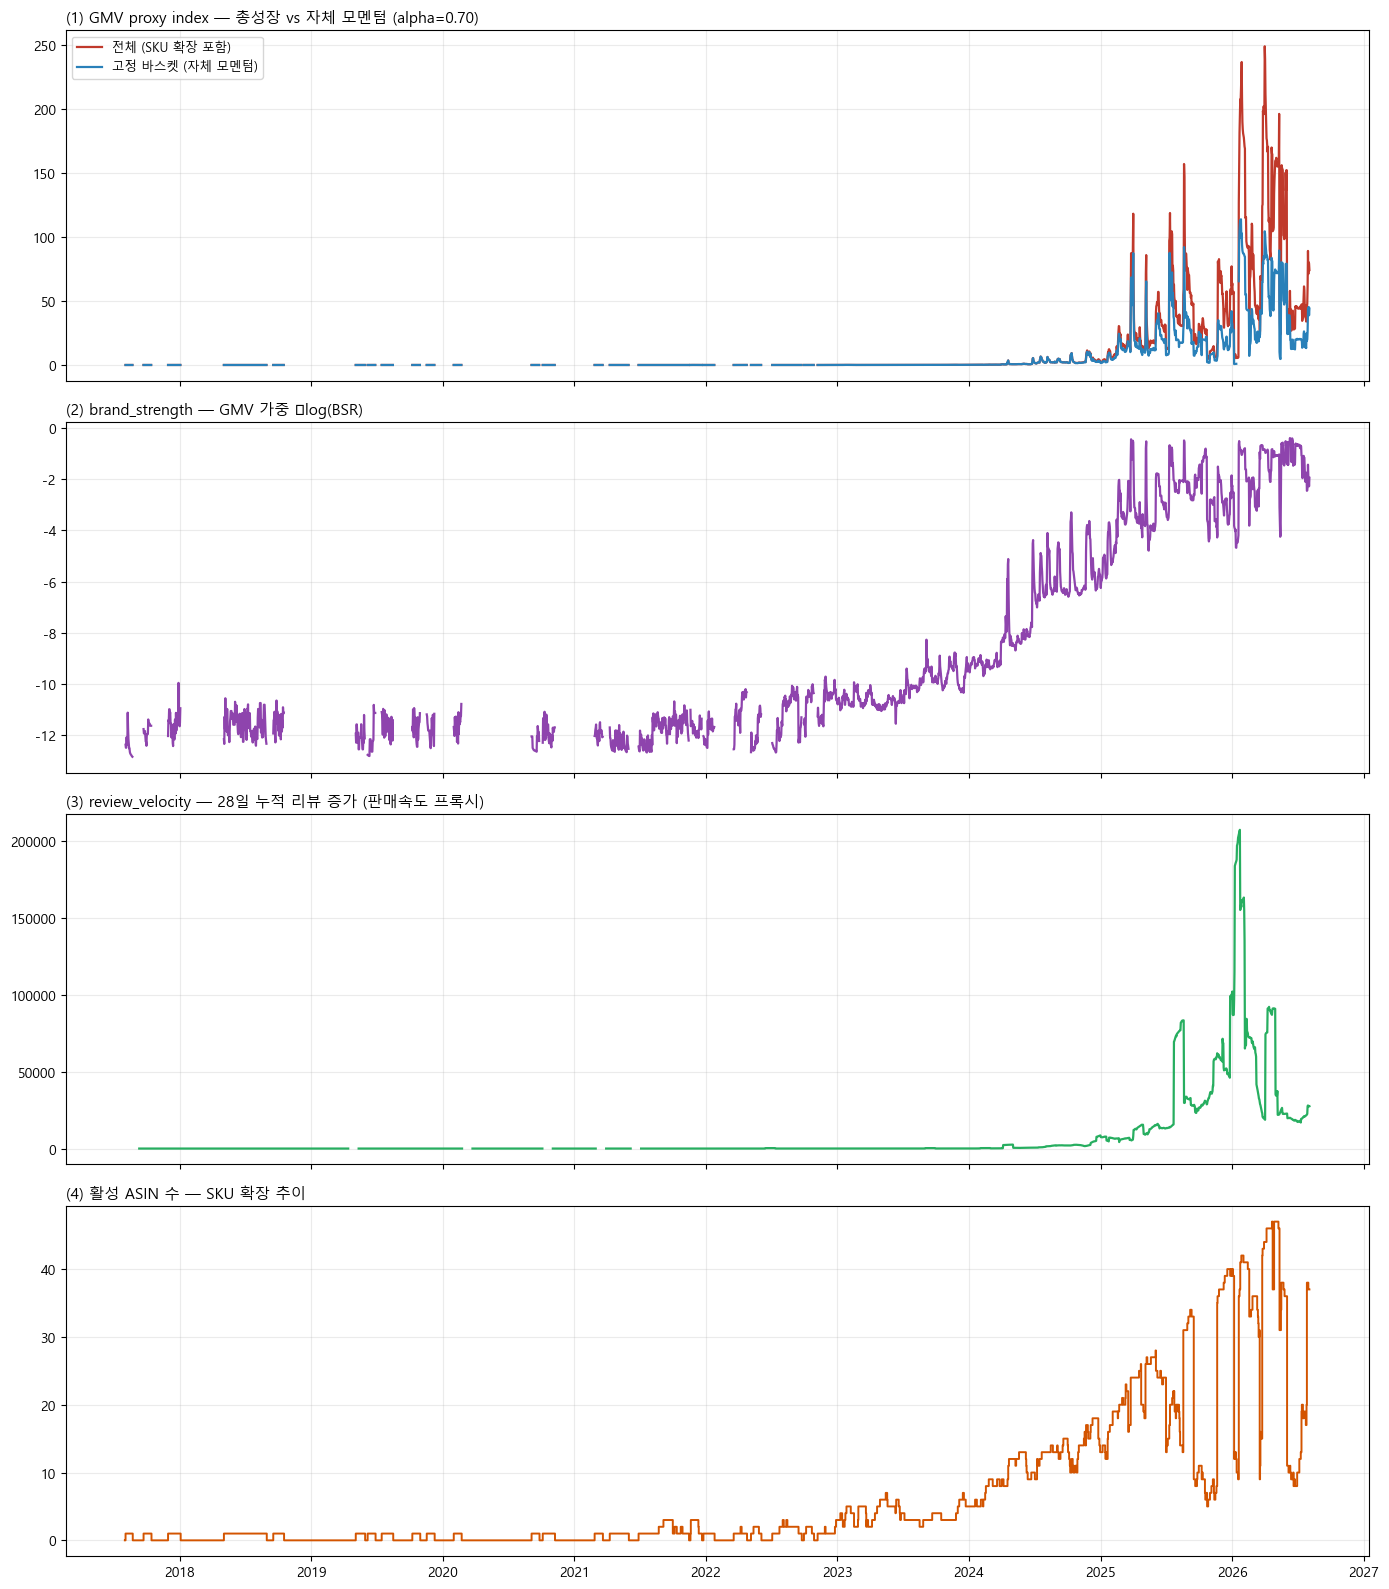

In [19]:
if SHOW_PLOTS and not idx_df.empty:
    import matplotlib
    import matplotlib.pyplot as plt

    for _f in ["Malgun Gothic", "AppleGothic", "NanumGothic", "DejaVu Sans"]:
        try:
            matplotlib.rcParams["font.family"] = _f
            break
        except Exception:
            continue
    matplotlib.rcParams["axes.unicode_minus"] = False

    fig, axes = plt.subplots(4, 1, figsize=(FIG_SIZE[0], FIG_SIZE[1] * 4), sharex=True)

    ax = axes[0]
    ax.plot(idx_df.index, idx_df["gmv_index_all"], color="#c0392b",
            linewidth=1.6, label="전체 (SKU 확장 포함)")
    ax.plot(idx_df.index, idx_df["gmv_index_fixed"], color="#2980b9",
            linewidth=1.6, label="고정 바스켓 (자체 모멘텀)")
    ax.set_title("(1) GMV proxy index — 총성장 vs 자체 모멘텀 (alpha=%.2f)" % ALPHA,
                 fontsize=11, loc="left")
    ax.legend(fontsize=9); ax.grid(alpha=0.25)

    ax = axes[1]
    ax.plot(idx_df.index, idx_df["brand_strength"], color="#8e44ad", linewidth=1.6)
    ax.set_title("(2) brand_strength — GMV 가중 −log(BSR)", fontsize=11, loc="left")
    ax.grid(alpha=0.25)

    ax = axes[2]
    ax.plot(idx_df.index, idx_df["review_velocity"], color="#27ae60", linewidth=1.6)
    ax.set_title("(3) review_velocity — 28일 누적 리뷰 증가 (판매속도 프록시)",
                 fontsize=11, loc="left")
    ax.grid(alpha=0.25)

    ax = axes[3]
    ax.plot(idx_df.index, idx_df["n_active_asin"], color="#d35400",
            linewidth=1.4, drawstyle="steps-post")
    ax.set_title("(4) 활성 ASIN 수 — SKU 확장 추이", fontsize=11, loc="left")
    ax.grid(alpha=0.25)

    plt.tight_layout(); plt.show()


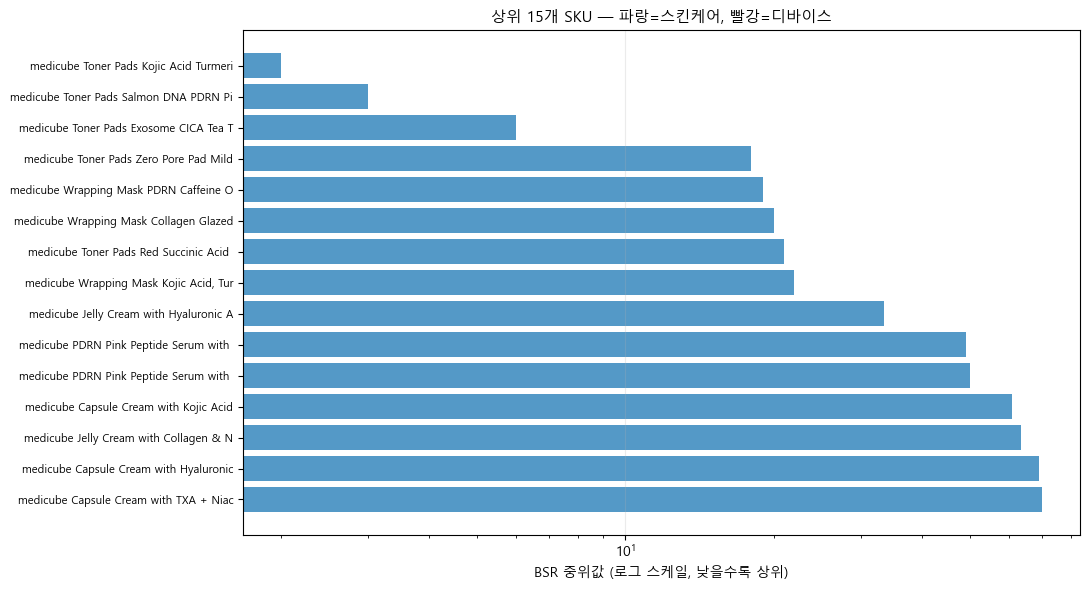

In [20]:
if SHOW_PLOTS and len(qc):
    import matplotlib.pyplot as plt

    top = qc.nsmallest(15, "bsr_median")
    fig, ax = plt.subplots(figsize=(11, 6))
    colors = ["#c0392b" if v else "#2980b9" for v in top["is_device"].fillna(0)]
    ax.barh(range(len(top)), top["bsr_median"], color=colors, alpha=0.8)
    ax.set_yticks(range(len(top)))
    ax.set_yticklabels([t[:38] for t in top["title"].astype(str)], fontsize=8)
    ax.invert_yaxis()
    ax.set_xscale("log")
    ax.set_xlabel("BSR 중위값 (로그 스케일, 낮을수록 상위)")
    ax.set_title("상위 15개 SKU — 파랑=스킨케어, 빨강=디바이스", fontsize=11)
    ax.grid(alpha=0.25, axis="x")
    plt.tight_layout(); plt.show()


## 13. 실행 요약

In [21]:
print("=" * 78)
print("APR Amazon/Keepa 파이프라인 — 실행 요약")
print("=" * 78)
print("  vintage        : %s" % COLLECTED_AT_EFF)
print("  대상           : %s (%s) / %s" % (COMPANY, TICKER, DOMAIN))
print("  ASIN 발굴      : %d개" % len(ASINS))
print("  파싱 성공      : %d개" % len(meta_df))
if len(panel):
    print("  패널 기간      : %s ~ %s (%d행)"
          % (panel["date"].min().date(), panel["date"].max().date(), len(panel)))
if not idx_df.empty:
    print("  지수 관측치    : %d일" % len(idx_df))
    print("  고정 바스켓    : %d개 ASIN" % idx_df["basket_size"].iloc[0])
print("  실적 앵커      : %d개 분기" % len(apr_df))
print("  DB 적재        : %s" % ("완료" if (SAVE_TO_DB and DB_AVAILABLE) else "미실행"))
ts_ = token_status()
if ts_.get("tokens_left") is not None:
    print("  토큰 잔량      : %d" % ts_["tokens_left"])
    used = sum([r.get("tokens_used") or 0 for r in collect_log_rows])
    print("  이번 실행 소모 : %d 토큰" % used)
print()
print("  [주의] BSR은 순위이지 판매량이 아닙니다. ALPHA는 자유 파라미터이며")
print("         민감도 표에서 부호가 뒤집히면 그 결과는 신뢰할 수 없습니다.")
print("         Google Trends 지표와 교차 확인 후 해석하십시오.")
print("=" * 78)


APR Amazon/Keepa 파이프라인 — 실행 요약
  vintage        : 2026-08-03
  대상           : APR (A278470) / US
  ASIN 발굴      : 50개
  파싱 성공      : 50개
  패널 기간      : 2017-08-02 ~ 2026-08-03 (32060행)
  지수 관측치    : 3289일
  고정 바스켓    : 13개 ASIN
  실적 앵커      : 0개 분기
  DB 적재        : 완료
  토큰 잔량      : 1039
  이번 실행 소모 : 100 토큰

  [주의] BSR은 순위이지 판매량이 아닙니다. ALPHA는 자유 파라미터이며
         민감도 표에서 부호가 뒤집히면 그 결과는 신뢰할 수 없습니다.
         Google Trends 지표와 교차 확인 후 해석하십시오.


---

## 다음 단계

1. **`APR_ACTUALS` 채우기** — 이게 없으면 11장 전체가 무의미하다. IR 자료에서
   분기별 미국(또는 북미) 매출을 확보하는 것이 이 파이프라인의 실질적 병목이다.
2. **ALPHA 민감도 확인** — 전 구간 부호 일관성이 없으면 지수 설계를 다시 봐야 한다.
3. **주 1회 증분 실행** — Keepa는 과거를 소급해 주므로 며칠 놓쳐도 구멍이 안 생긴다.
   토큰 소모는 30 ASIN 기준 60토큰 수준으로 무시 가능하다.
4. **다종목 확장** — `TICKER`/`BRAND_NAMES`만 바꿔 재실행하면 같은 테이블에 누적된다.
   실리콘투·삼양식품·코스맥스 등으로 넓히면 패널 관측치가 늘어 검증력이 올라간다.
   단일 종목 10개 관측치의 한계는 종목 수로만 우회할 수 있다.

## 알려진 한계

| 항목 | 내용 |
|---|---|
| ALPHA | 카테고리·시즌별로 달라지는 자유 파라미터. 단일 값 신뢰 금지 |
| 절대 판매량 | 추정하지 않음. 상대 변화만 유효 |
| 품절 왜곡 | 마스킹했으나 재고 회복 직후 BSR 급등도 수요 신호가 아님 |
| variation | parent/child 리뷰 이중계상 가능. `parent_asin` 기록만 해둔 상태 |
| 3P 판매자 | 공식 스토어 외 리셀러 ASIN이 섞이면 브랜드 집계가 부정확해짐 |
| 채널 사각 | TikTok Shop·Ulta·DTC 매출은 Amazon BSR에 전혀 반영되지 않음 |

## 보안

- `keepa_config.json` 을 `.gitignore` 에 추가할 것
- 채팅·이메일 등에 노출된 키는 Keepa 계정에서 **재발급(regenerate)** 할 것

---
*V4 · 2026-08 · 짝 노트북: `apr_us_google_trends_v4.ipynb`*